<a href="https://colab.research.google.com/github/farhanh1418/mycodes/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --------------------------
# 1) PINN definition
# --------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return x * self.layers(x)  # Embed u(0)=0

# --------------------------
# 2) Physical parameters
# --------------------------
E = 210e9
A = 0.01
P = 1e6

x_test = torch.linspace(0, 1, 10).unsqueeze(1)
u_true = (P/(E*A)) * x_test.numpy()

# --------------------------
# 3) Hyperparameter grid
# --------------------------
learning_rates = [1e-5, 5e-5, 1e-4]
bc_weights = [0.01, 0.1, 1.0]
N_fs = [100, 200, 500]

results = []

# --------------------------
# 4) Loop over hyperparameters
# --------------------------
for lr in learning_rates:
    for bc_weight in bc_weights:
        for N_f in N_fs:
            # Initialize model and optimizer
            model = PINN()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Collocation points
            x_f = torch.rand(N_f, 1, requires_grad=True)
            x1 = torch.tensor([[1.0]], requires_grad=True)

            # Training loop (short for hyperparameter search)
            for epoch in range(2000):
                optimizer.zero_grad()

                u = model(x_f)
                du_dx = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                d2u_dx2 = torch.autograd.grad(du_dx, x_f, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
                loss_pde = torch.mean(d2u_dx2**2)

                u1 = model(x1)
                du_dx_1 = torch.autograd.grad(u1, x1, grad_outputs=torch.ones_like(u1), create_graph=True)[0]
                loss_bc = ((E*A*du_dx_1 - P)**2).mean()

                loss = loss_pde + bc_weight*loss_bc
                loss.backward()
                optimizer.step()

            # Evaluate on test points
            u_pred = model(x_test).detach().numpy()
            mae = np.mean(np.abs(u_pred - u_true))

            results.append({
                "lr": lr,
                "bc_weight": bc_weight,
                "N_f": N_f,
                "MAE": mae
            })
            print(f"lr={lr}, bc_weight={bc_weight}, N_f={N_f}, MAE={mae:.6e}")

# --------------------------
# 5) Find best combination
# --------------------------
best = min(results, key=lambda x: x["MAE"])
print("\nBest hyperparameters:")
print(best)


lr=1e-05, bc_weight=0.01, N_f=100, MAE=3.175827e-02
lr=1e-05, bc_weight=0.01, N_f=200, MAE=1.548559e-02
lr=1e-05, bc_weight=0.01, N_f=500, MAE=2.681196e-02
lr=1e-05, bc_weight=0.1, N_f=100, MAE=6.181923e-03
lr=1e-05, bc_weight=0.1, N_f=200, MAE=7.434893e-03
lr=1e-05, bc_weight=0.1, N_f=500, MAE=2.664130e-02
lr=1e-05, bc_weight=1.0, N_f=100, MAE=1.464068e-02
lr=1e-05, bc_weight=1.0, N_f=200, MAE=7.599487e-02
lr=1e-05, bc_weight=1.0, N_f=500, MAE=5.353336e-02
lr=5e-05, bc_weight=0.01, N_f=100, MAE=3.068306e-02
lr=5e-05, bc_weight=0.01, N_f=200, MAE=2.860916e-03
lr=5e-05, bc_weight=0.01, N_f=500, MAE=5.093878e-03
lr=5e-05, bc_weight=0.1, N_f=100, MAE=1.584768e-02
lr=5e-05, bc_weight=0.1, N_f=200, MAE=3.485512e-02
lr=5e-05, bc_weight=0.1, N_f=500, MAE=1.750827e-02
lr=5e-05, bc_weight=1.0, N_f=100, MAE=2.263995e-02
lr=5e-05, bc_weight=1.0, N_f=200, MAE=1.777348e-02
lr=5e-05, bc_weight=1.0, N_f=500, MAE=7.605068e-02
lr=0.0001, bc_weight=0.01, N_f=100, MAE=2.604342e-02
lr=0.0001, bc_weight=0.

Epoch 0, Total Loss: 2.2225e+02, PDE Loss: 2.0950e-15, BC Loss: 2.2225e+05
Epoch 1000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 2000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 3000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 4000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 5000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 6000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 7000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 8000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00
Epoch 9000, Total Loss: 3.6448e-14, PDE Loss: 3.6448e-14, BC Loss: 0.0000e+00


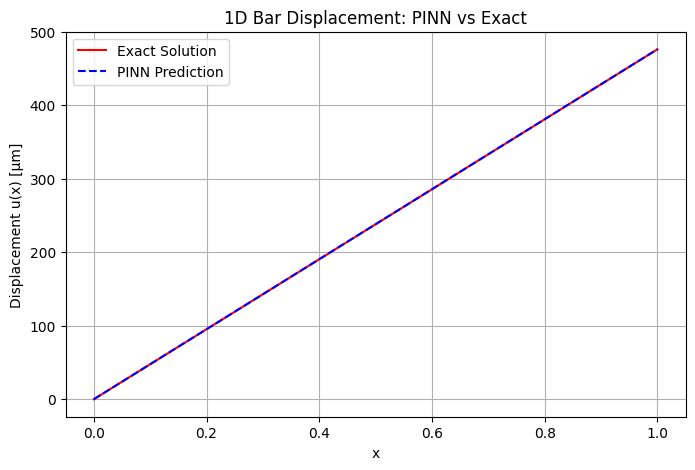

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --------------------------
# 2) Physical parameters
# --------------------------
E = 210e9      # Pa
A = 0.01       # m^2
P = 1e6        # N


slope = P/(E*A)



# --------------------------
# 1) Define PINN with embedded Dirichlet BC u(0)=0
# --------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return slope * x + 1e-6 * x * self.layers(x)  # ensures u(0)=0


# --------------------------
# 3) Collocation points
# --------------------------
N_f = 500
x_f = torch.rand(N_f, 1, requires_grad=True)
x1 = torch.tensor([[1.0]], requires_grad=True)  # traction BC at x=1

# --------------------------
# 4) Model and optimizer
# --------------------------
model = PINN()
lr = 5e-5
bc_weight = 0.001
optimizer = optim.Adam(model.parameters(), lr=lr)

# --------------------------
# 5) Training loop
# --------------------------
epochs = 10000  # train longer for convergence
for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE residual
    u = model(x_f)
    du_dx = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x_f, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    loss_pde = torch.mean(d2u_dx2**2)

    # Traction BC
    u1 = model(x1)
    du_dx_1 = torch.autograd.grad(u1, x1, grad_outputs=torch.ones_like(u1), create_graph=True)[0]
    loss_bc = ((E*A*du_dx_1 - P)**2).mean()

    # Total loss
    loss = loss_pde + bc_weight * loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, PDE Loss: {loss_pde.item():.4e}, BC Loss: {loss_bc.item():.4e}")

import matplotlib.pyplot as plt

# --------------------------
# 6) Evaluate and plot values
# --------------------------
x_test = torch.linspace(0, 1, 100).unsqueeze(1)  # finer grid for smooth curves
u_pred = model(x_test).detach().numpy()
u_true = (P/(E*A)) * x_test.numpy()

# Convert to micrometers for readability
u_pred_um = u_pred * 1e6
u_true_um = u_true * 1e6

plt.figure(figsize=(8,5))
plt.plot(x_test, u_true_um, 'r-', label='Exact Solution')
plt.plot(x_test, u_pred_um, 'b--', label='PINN Prediction')
plt.xlabel('x')
plt.ylabel('Displacement u(x) [µm]')
plt.title('1D Bar Displacement: PINN vs Exact')
plt.legend()
plt.grid(True)
plt.show()



Epoch 0, Total Loss: 9.0569e+00, PDE Loss: 2.3536e-18, BC Loss: 9.0569e+03
Epoch 1000, Total Loss: 3.5690e-15, PDE Loss: 3.7379e-18, BC Loss: 3.5652e-12
Epoch 2000, Total Loss: 1.2318e-16, PDE Loss: 3.7379e-18, BC Loss: 1.1944e-13
Epoch 3000, Total Loss: 1.2318e-16, PDE Loss: 3.7379e-18, BC Loss: 1.1944e-13
Epoch 4000, Total Loss: 3.5690e-15, PDE Loss: 3.7379e-18, BC Loss: 3.5652e-12
Epoch 5000, Total Loss: 3.5690e-15, PDE Loss: 3.7379e-18, BC Loss: 3.5652e-12
Epoch 6000, Total Loss: 1.2318e-16, PDE Loss: 3.7379e-18, BC Loss: 1.1944e-13
Epoch 7000, Total Loss: 1.2318e-16, PDE Loss: 3.7380e-18, BC Loss: 1.1944e-13
Epoch 8000, Total Loss: 2.3459e-16, PDE Loss: 3.7380e-18, BC Loss: 2.3086e-13
Epoch 9000, Total Loss: 1.2318e-16, PDE Loss: 3.7380e-18, BC Loss: 1.1944e-13


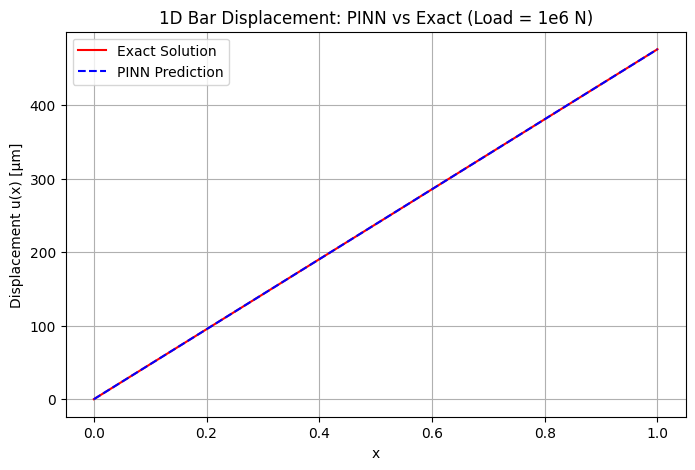

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 2) Physical parameters
# --------------------------
E = 210e9      # Pa
A = 0.01       # m^2

# --------------------------
# 1) Define parametric PINN with embedded Dirichlet BC u(0)=0
# --------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 50),  # x and P as inputs
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, P):
        slope = P / (E*A)
        inputs = torch.cat([x, P], dim=1)  # shape [N,2]
        return slope * x + 1e-6 * x * self.layers(inputs)

# --------------------------
# 3) Collocation points for x and P
# --------------------------
N_x = 100       # points along the bar
N_P = 50        # number of loads

# x values (random inside the domain)
x_f = torch.rand(N_x, 1)
# P values (range from 1 N to 1e6 N)
P_samples = torch.linspace(1, 1e6, N_P).unsqueeze(1)

# Create all combinations for collocation points
x_collocation = x_f.repeat(N_P,1)
P_collocation = P_samples.repeat_interleave(N_x, dim=0)
x_collocation.requires_grad_(True)
P_collocation.requires_grad_(True)

# Boundary points at x=1
x1 = torch.ones((N_P,1), requires_grad=True)
P1 = P_samples  # BC loads

# --------------------------
# 4) Model and optimizer
# --------------------------
model = PINN()
lr = 5e-5
bc_weight = 0.001
optimizer = optim.Adam(model.parameters(), lr=lr)

# --------------------------
# 5) Training loop
# --------------------------
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE residual
    u = model(x_collocation, P_collocation)
    du_dx = torch.autograd.grad(u, x_collocation, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x_collocation, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    loss_pde = torch.mean(d2u_dx2**2)

    # Traction BC at x=1
    u1 = model(x1, P1)
    du_dx_1 = torch.autograd.grad(u1, x1, grad_outputs=torch.ones_like(u1), create_graph=True)[0]
    loss_bc = torch.mean((E*A*du_dx_1 - P1)**2)

    # Total loss
    loss = loss_pde + bc_weight * loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, PDE Loss: {loss_pde.item():.4e}, BC Loss: {loss_bc.item():.4e}")

# --------------------------
# 6) Evaluate and plot for an example load
# --------------------------
x_test = torch.linspace(0, 1, 100).unsqueeze(1)
P_test = torch.tensor([[1e6]]*100)  # choose load to visualize

u_pred = model(x_test, P_test).detach().numpy()
u_true = (P_test.numpy()/(E*A)) * x_test.numpy()

# Convert to micrometers
u_pred_um = u_pred * 1e6
u_true_um = u_true * 1e6

plt.figure(figsize=(8,5))
plt.plot(x_test, u_true_um, 'r-', label='Exact Solution')
plt.plot(x_test, u_pred_um, 'b--', label='PINN Prediction')
plt.xlabel('x')
plt.ylabel('Displacement u(x) [µm]')
plt.title('1D Bar Displacement: PINN vs Exact (Load = 1e6 N)')
plt.legend()
plt.grid(True)
plt.show()
